<a href="https://colab.research.google.com/github/ChengxuanOuyang/ChengxuanOuyang/blob/main/ATLAS_Cut_Based.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset successfully loaded. Total events: 77176

----------------------------------------------------------------------
Processing Parameter: mBB | Cut: mBB > 90 and mBB < 150
----------------------------------------------------------------------


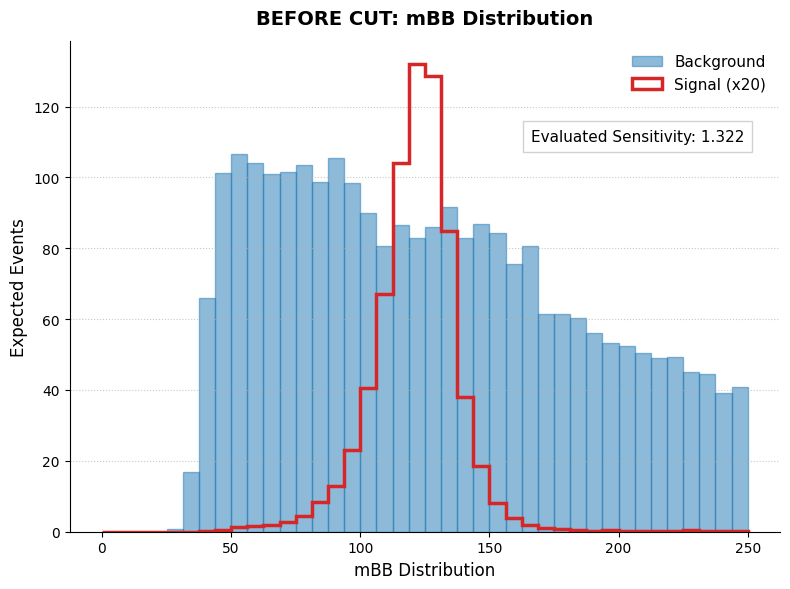

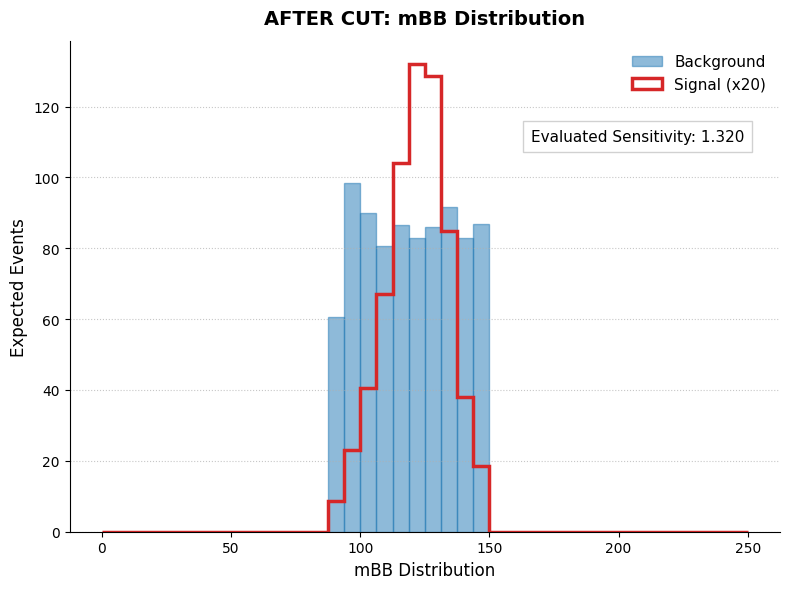


----------------------------------------------------------------------
Processing Parameter: dRBB | Cut: dRBB > 0 and dRBB < 2.0
----------------------------------------------------------------------


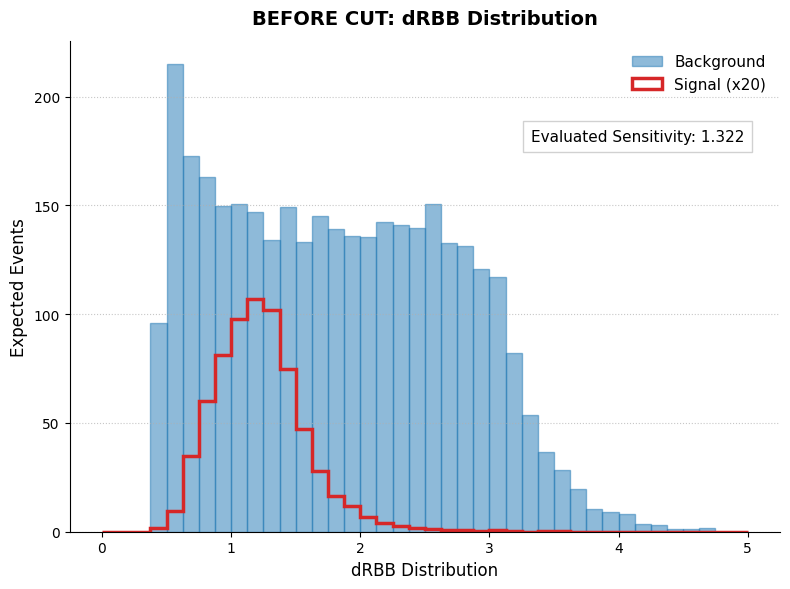

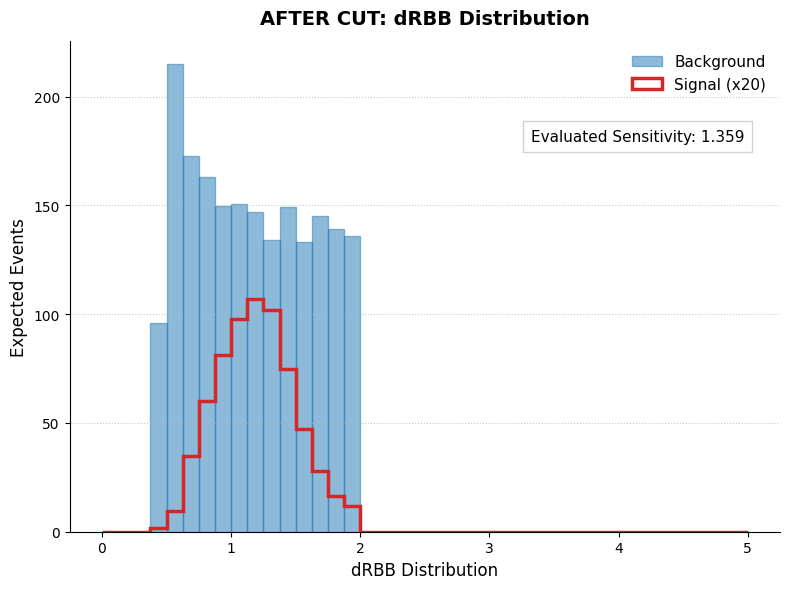


----------------------------------------------------------------------
Processing Parameter: pTV | Cut: pTV > 150
----------------------------------------------------------------------


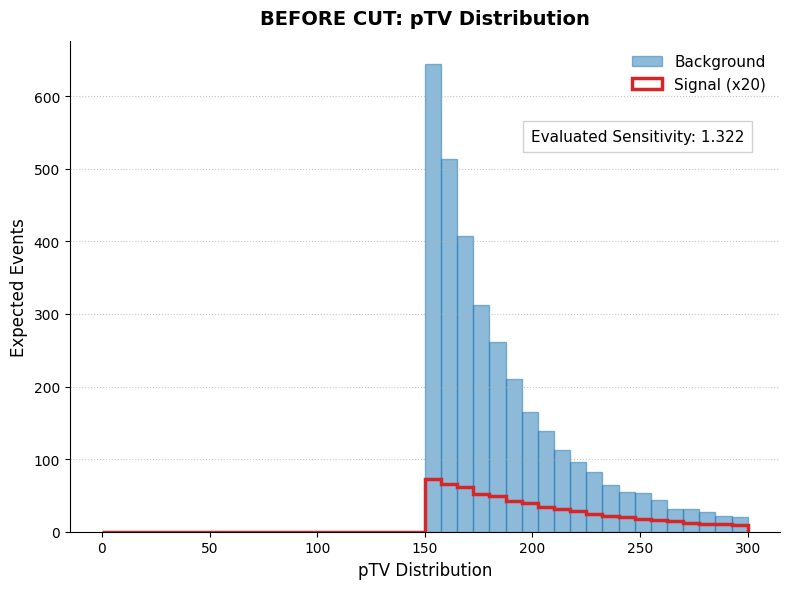

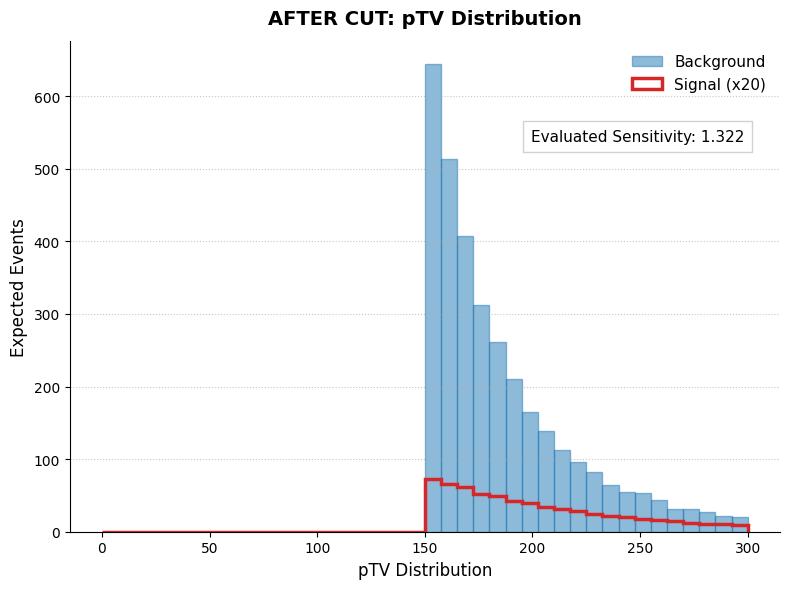


----------------------------------------------------------------------
Processing Parameter: MET | Cut: MET > 30
----------------------------------------------------------------------


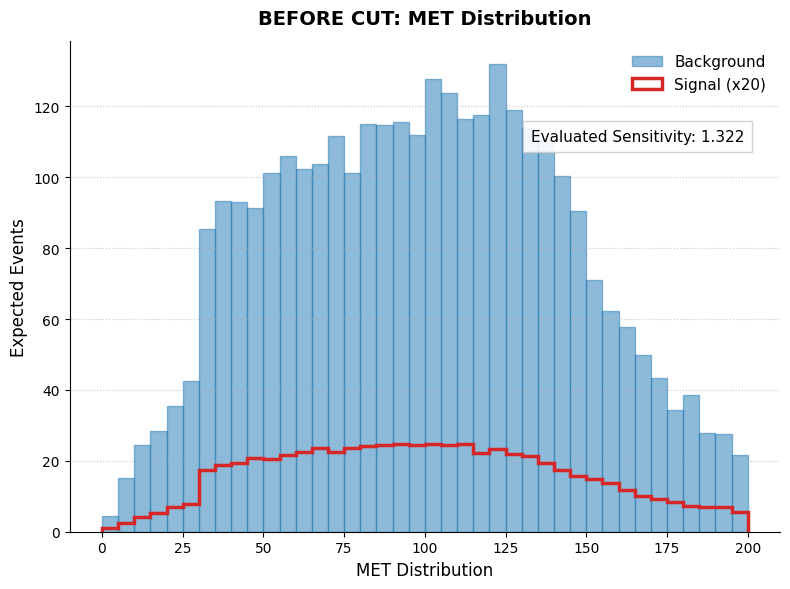

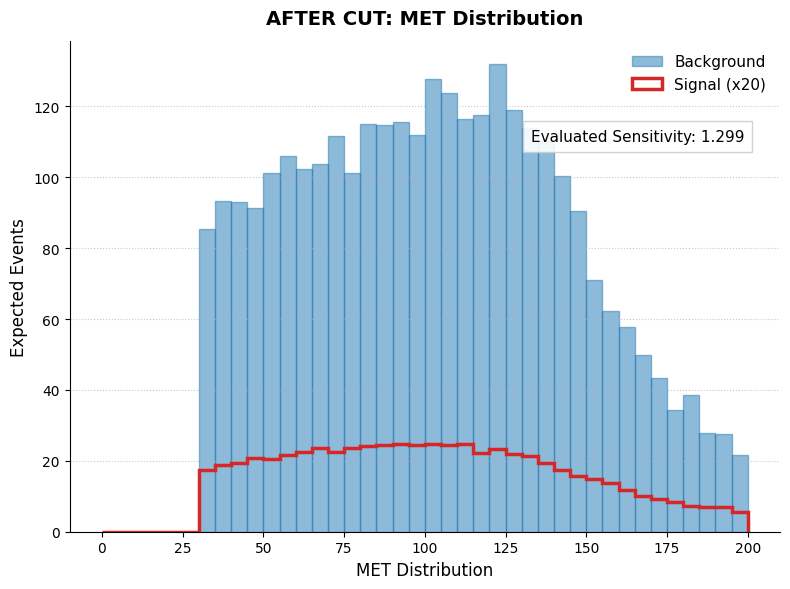


----------------------------------------------------------------------
Processing Parameter: Mtop | Cut: Mtop > 0 and (Mtop < 150 or Mtop > 200)
----------------------------------------------------------------------


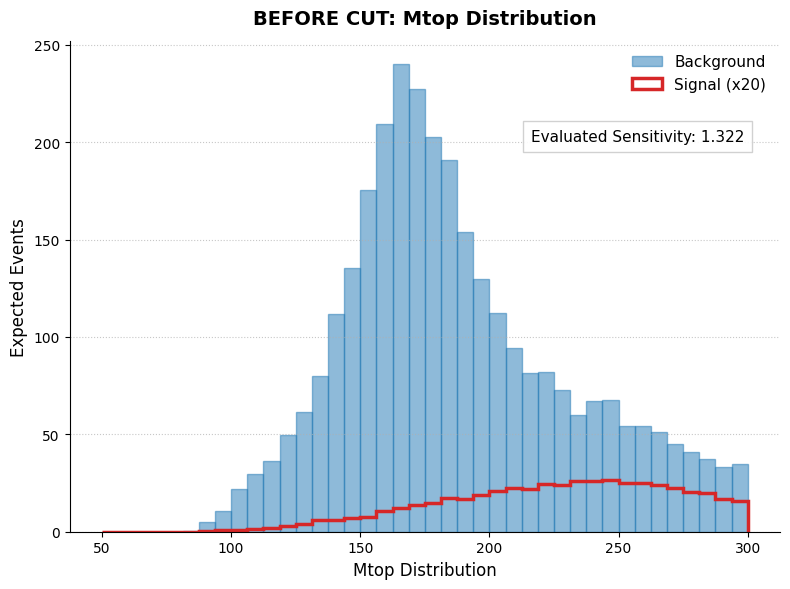

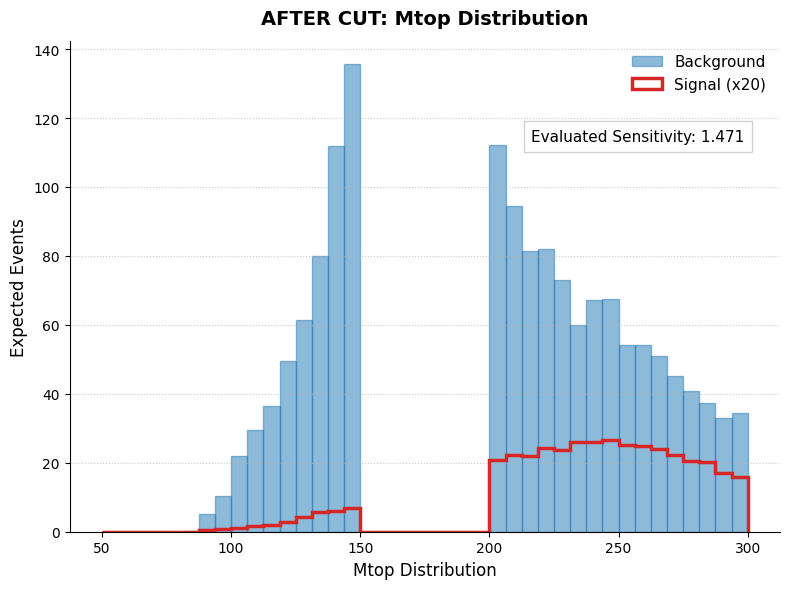


FINAL SUMMARY: SINGLE PARAMETER CUT SENSITIVITIES
Parameter Cut Applied                              Sens. Before  Sens. After Improvement
 mBB                       mBB > 90 and mBB < 150 1.322         1.320        -0.18%     
dRBB                      dRBB > 0 and dRBB < 2.0 1.322         1.359         2.75%     
 pTV                                    pTV > 150 1.322         1.322         0.00%     
 MET                                     MET > 30 1.322         1.299        -1.76%     
Mtop      Mtop > 0 and (Mtop < 150 or Mtop > 200) 1.322         1.471        11.26%     



In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def load_and_preprocess_data(filepath: str) -> pd.DataFrame:
    """
    Loads the ATLAS dataset, converts energy/mass variables from MeV to GeV,
    and drops rows with critical missing values.
    """
    try:
        df = pd.read_csv(filepath)
        print(f"Dataset successfully loaded. Total events: {len(df)}")
    except FileNotFoundError:
        print(f"Error: Dataset not found at {filepath}.")
        raise

    # Convert MeV to GeV
    mev_columns = ['mBB', 'pTV', 'MET', 'Mtop', 'pTB1', 'pTB2', 'pTJ3', 'mBBJ', 'mTW']
    for col in mev_columns:
        if col in df.columns:
            df[col] = df[col] / 1000.0

    return df

def calculate_sensitivity_mbb(df: pd.DataFrame, weight_col: str, bins: int = 30, mbb_range: tuple = (0, 250)) -> float:
    """
    Calculates the bin-by-bin sensitivity using the di-jet mass (mBB) distribution.
    Formula: sqrt(sum(S_i^2 / B_i))
    """
    is_sig = (df['Class'] == 1) | (df['Class'] == 1.0) | (df['Class'] == 's') | (df['Class'] == '1')
    df_sig = df[is_sig]
    df_bkg = df[~is_sig]

    s_hist, _ = np.histogram(df_sig['mBB'], bins=bins, range=mbb_range, weights=df_sig[weight_col])
    b_hist, _ = np.histogram(df_bkg['mBB'], bins=bins, range=mbb_range, weights=df_bkg[weight_col])

    b_hist = np.where(b_hist <= 0, 1e-9, b_hist)
    return float(np.sqrt(np.sum((s_hist ** 2) / b_hist)))

def plot_distribution(df: pd.DataFrame, var: str, var_range: tuple, weight_col: str,
                      title: str, sensitivity: float, is_after_cut: bool = False):
    """
    Plots the distribution matching the style of the ATLAS starter notebooks.
    Positions the sensitivity statistics immediately below the legend.
    """
    is_sig = (df['Class'] == 1) | (df['Class'] == 1.0) | (df['Class'] == 's') | (df['Class'] == '1')

    plt.figure(figsize=(8, 6))

    # Style matches typical HEP notebooks: semi-transparent blue for background, bold red step for signal
    plt.hist(df[~is_sig][var], bins=40, range=var_range, weights=df[~is_sig][weight_col],
             alpha=0.5, color='#1f77b4', edgecolor='#1f77b4', label='Background')

    scale_factor = 20
    plt.hist(df[is_sig][var], bins=40, range=var_range, weights=df[is_sig][weight_col] * scale_factor,
             histtype='step', color='#d62728', linewidth=2.5, label=f'Signal (x{scale_factor})')

    plt.title(title, fontsize=14, pad=12, fontweight='bold')
    plt.xlabel(f"{var} Distribution", fontsize=12)
    plt.ylabel("Expected Events", fontsize=12)

    # Legend at the top right
    leg = plt.legend(loc='upper right', frameon=False, fontsize=11)

    # Sensitivity text box placed directly below the legend
    stats_text = f"Evaluated Sensitivity: {sensitivity:.3f}"
    plt.text(0.95, 0.82, stats_text, transform=plt.gca().transAxes,
             fontsize=11, verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='square,pad=0.5', facecolor='white', edgecolor='#cccccc', alpha=0.9))

    plt.grid(axis='y', linestyle=':', alpha=0.7)
    # Remove top and right spines for a cleaner academic look
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

def evaluate_parameter_before_after(df: pd.DataFrame, var: str, cut_query: str, var_range: tuple):
    """
    Evaluates a single parameter, generates two plots, and returns the sensitivities
    for the final summary table.
    """
    weight_col = 'EventWeight' if 'EventWeight' in df.columns else 'training_weight'
    df_clean = df.dropna(subset=[var, 'mBB', weight_col, 'Class']).copy()

    print(f"\n{'-'*70}\nProcessing Parameter: {var} | Cut: {cut_query}\n{'-'*70}")

    # --- BEFORE CUT ---
    sens_before = calculate_sensitivity_mbb(df_clean, weight_col)
    title_before = f"BEFORE CUT: {var} Distribution"
    plot_distribution(df_clean, var, var_range, weight_col, title_before, sens_before, is_after_cut=False)

    # --- AFTER CUT ---
    df_cut = df_clean.query(cut_query)
    sens_after = calculate_sensitivity_mbb(df_cut, weight_col)
    title_after = f"AFTER CUT: {var} Distribution"
    plot_distribution(df_cut, var, var_range, weight_col, title_after, sens_after, is_after_cut=True)

    return sens_before, sens_after

# ==========================================
# Main Execution Block
# ==========================================
if __name__ == "__main__":
    FILE_PATH = '/VHbb_data_2jet_train.csv'
    df_main = load_and_preprocess_data(FILE_PATH)

    # Defined cuts with physical motivations based on ATLAS literature
    physics_cuts = {
        'mBB':  ('mBB > 90 and mBB < 150', (0, 250)),
        'dRBB': ('dRBB > 0 and dRBB < 2.0', (0, 5)),
        'pTV':  ('pTV > 150', (0, 300)),
        'MET':  ('MET > 30', (0, 200)),
        'Mtop': ('Mtop > 0 and (Mtop < 150 or Mtop > 200)', (50, 300))
    }

    summary_results = []

    for variable, (query_string, plot_range) in physics_cuts.items():
        if variable in df_main.columns:
            s_before, s_after = evaluate_parameter_before_after(df_main, variable, query_string, plot_range)

            # Store results for the final summary table
            summary_results.append({
                'Parameter': variable,
                'Cut Applied': query_string,
                'Sens. Before': round(s_before, 3),
                'Sens. After': round(s_after, 3),
                'Improvement': f"{((s_after - s_before) / s_before) * 100:.2f}%" if s_before > 0 else "0.00%"
            })
        else:
            print(f"Warning: {variable} missing from dataset.")

    # --- Print Final Summary Table ---
    print("\n" + "="*85)
    print("FINAL SUMMARY: SINGLE PARAMETER CUT SENSITIVITIES")
    print("="*85)
    summary_df = pd.DataFrame(summary_results)
    print(summary_df.to_string(index=False, justify='left'))
    print("="*85 + "\n")

Dataset successfully loaded. Total initial events: 77176

Parameter Analysis: mBB  |  Applied Cut: mBB > 90 and mBB < 150


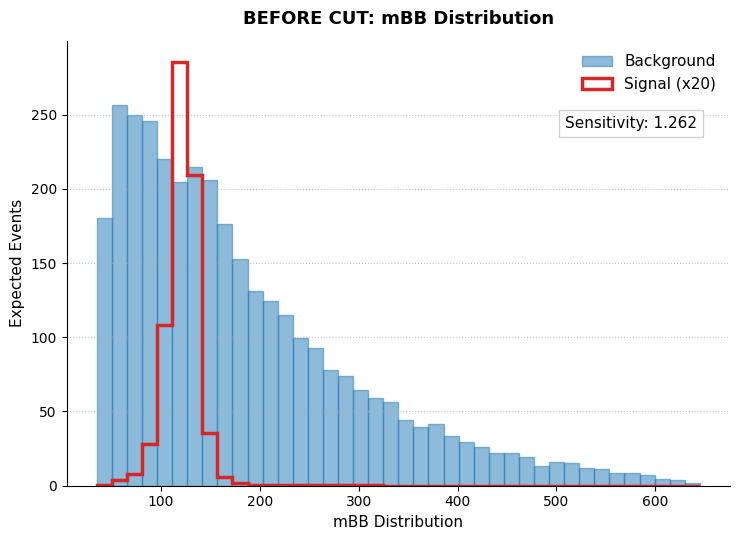

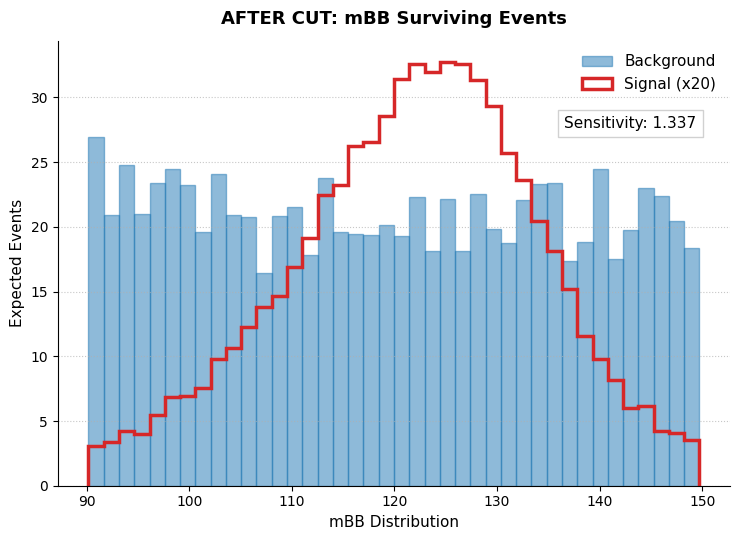


Parameter Analysis: dRBB  |  Applied Cut: dRBB > 0 and dRBB < 2.0


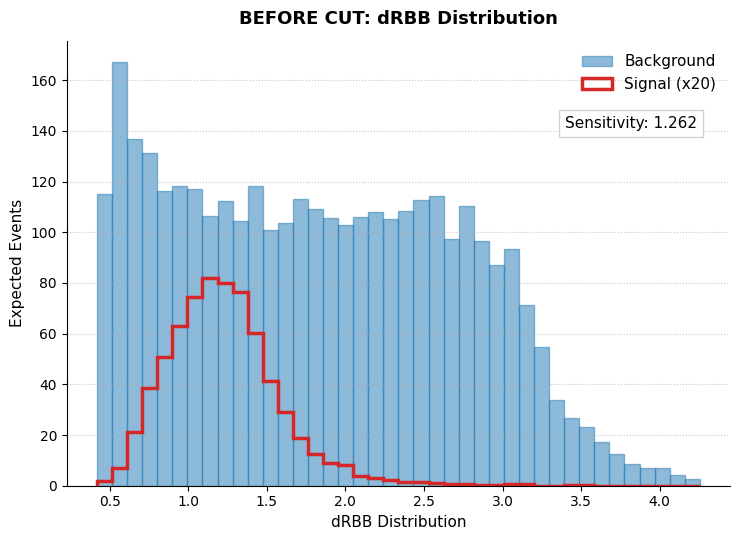

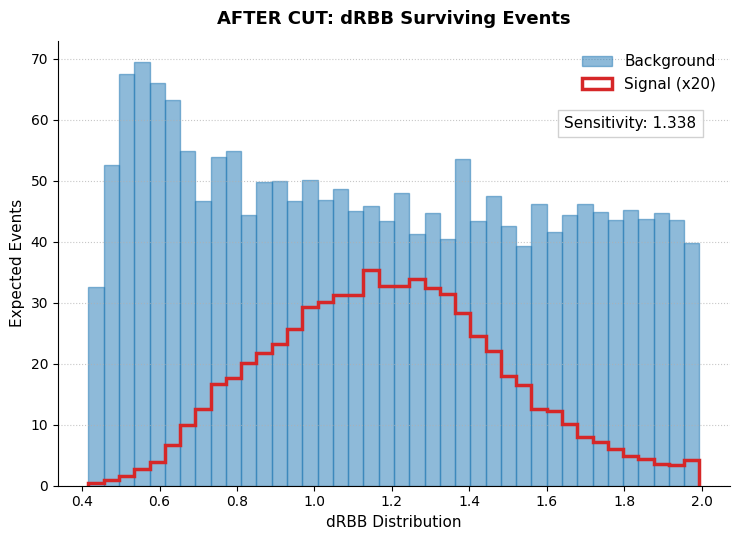


Parameter Analysis: pTV  |  Applied Cut: pTV > 150


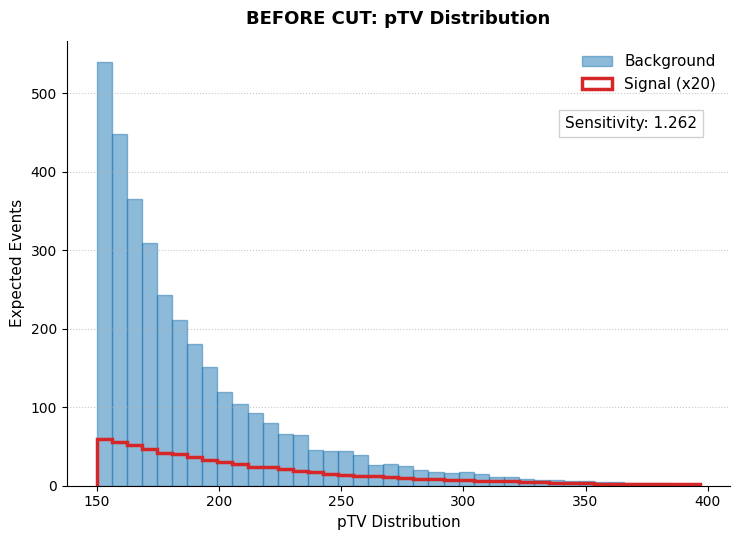

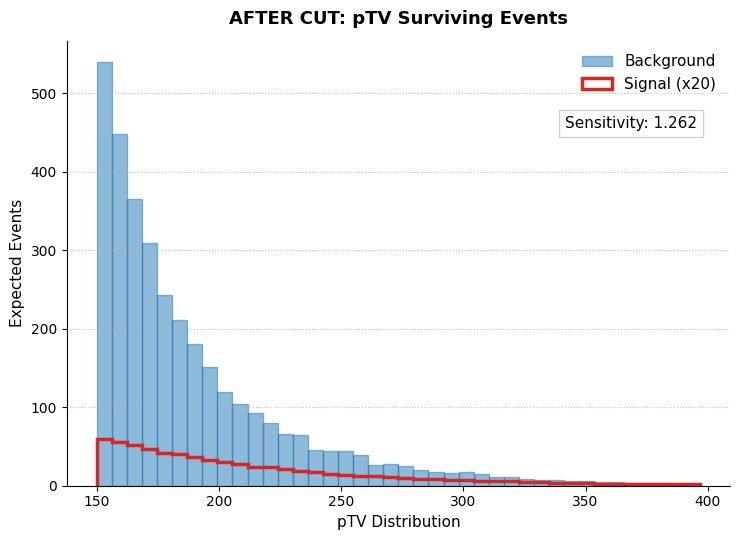


Parameter Analysis: MET  |  Applied Cut: MET > 30


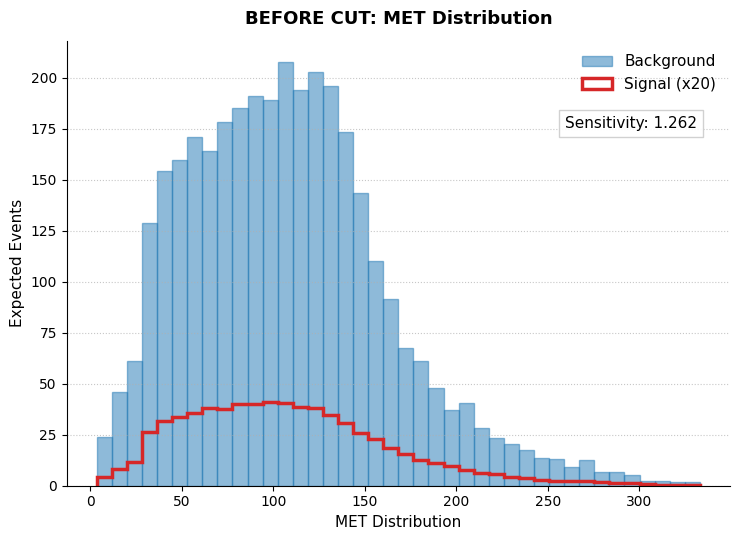

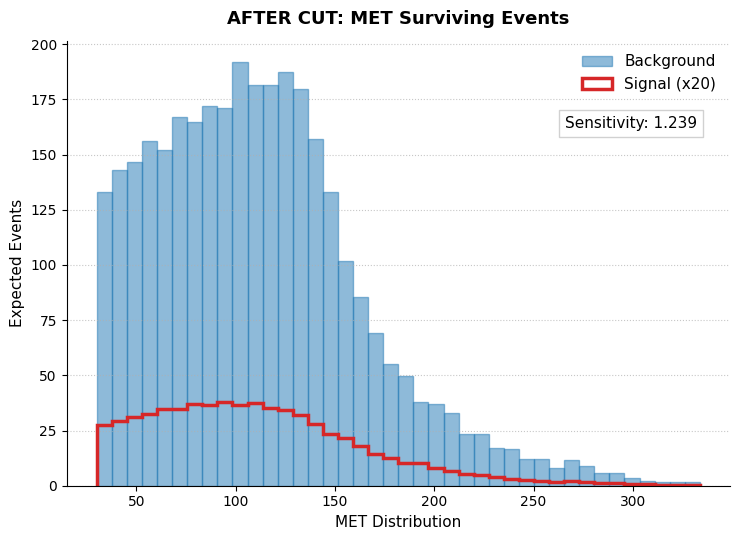


Parameter Analysis: Mtop  |  Applied Cut: Mtop > 0 and (Mtop < 150 or Mtop > 200)


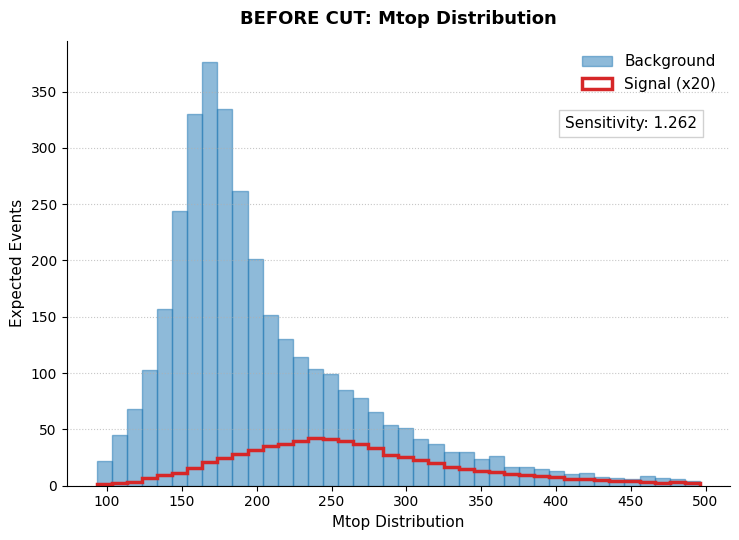

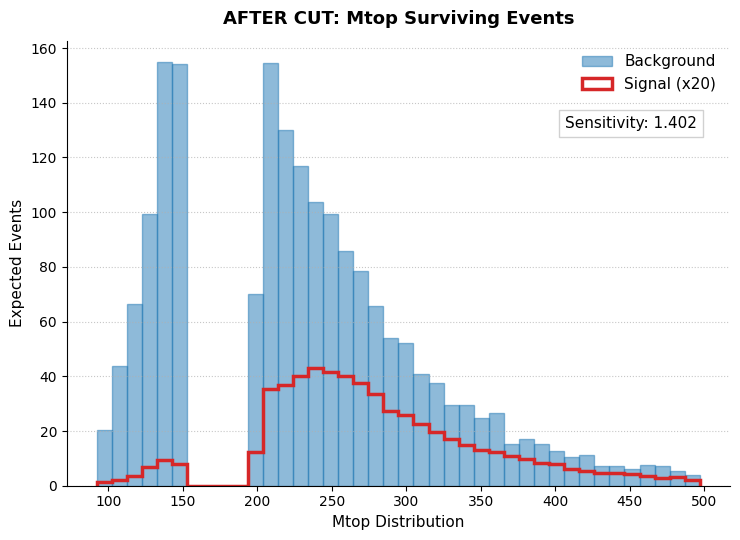



SUMMARY TABLE: CUT-BASED SENSITIVITY EVALUATION
References [1] ATLAS Phys. Lett. B 786 (2018), [2] ATLAS JHEP 01 (2015), [3] PRL 100 (2008)
Parameter Cut Applied                             Sens. Before Sens. After Improvement (%)
 mBB                       mBB > 90 and mBB < 150 1.262        1.337        5.99%         
dRBB                      dRBB > 0 and dRBB < 2.0 1.262        1.338        6.02%         
 pTV                                    pTV > 150 1.262        1.262        0.00%         
 MET                                     MET > 30 1.262        1.239       -1.80%         
Mtop      Mtop > 0 and (Mtop < 150 or Mtop > 200) 1.262        1.402       11.14%         



In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def load_and_preprocess_data(filepath: str) -> pd.DataFrame:
    """
    Loads the ATLAS dataset and converts energy variables from MeV to GeV.
    Drops critical missing values to ensure plotting stability.
    """
    try:
        df = pd.read_csv(filepath)
        print(f"Dataset successfully loaded. Total initial events: {len(df)}")
    except FileNotFoundError:
        print(f"Error: Dataset not found at {filepath}.")
        raise

    mev_columns = ['mBB', 'pTV', 'MET', 'Mtop', 'pTB1', 'pTB2', 'pTJ3', 'mBBJ', 'mTW']
    for col in mev_columns:
        if col in df.columns:
            df[col] = df[col] / 1000.0

    return df

def calculate_dynamic_sensitivity(df: pd.DataFrame, weight_col: str, bins: int = 30) -> float:
    """
    Calculates the signal sensitivity using DYNAMIC bin edges based on the current data range.
    This exactly replicates the methodology in the ATLAS starter notebooks, allowing
    sensitivity to mathematically increase as the analysis window narrows around the signal peak.
    """
    is_sig = (df['Class'] == 1) | (df['Class'] == 1.0) | (df['Class'] == 's') | (df['Class'] == '1')
    df_sig = df[is_sig]
    df_bkg = df[~is_sig]

    # Dynamically determine the range based on the surviving events in the current dataframe
    current_min, current_max = df['mBB'].min(), df['mBB'].max()

    s_hist, edges = np.histogram(df_sig['mBB'], bins=bins, range=(current_min, current_max), weights=df_sig[weight_col])
    b_hist, _ = np.histogram(df_bkg['mBB'], bins=edges, weights=df_bkg[weight_col])

    b_hist = np.where(b_hist <= 0, 1e-9, b_hist)
    return float(np.sqrt(np.sum((s_hist ** 2) / b_hist)))

def plot_academic_distribution(df: pd.DataFrame, var: str, weight_col: str,
                               title: str, sensitivity: float, is_after_cut: bool = False):
    """
    Generates an academic-style plot matching ATLAS standards.
    Sensitivity is placed cleanly under the top-right legend.
    """
    is_sig = (df['Class'] == 1) | (df['Class'] == 1.0) | (df['Class'] == 's') | (df['Class'] == '1')

    # Dynamically scale the x-axis based on data percentiles to ignore extreme outliers visually
    p_low, p_high = df[var].quantile(0.001), df[var].quantile(0.999)

    plt.figure(figsize=(7.5, 5.5))

    plt.hist(df[~is_sig][var], bins=40, range=(p_low, p_high), weights=df[~is_sig][weight_col],
             alpha=0.5, color='#1f77b4', edgecolor='#1f77b4', label='Background')

    scale_factor = 20
    plt.hist(df[is_sig][var], bins=40, range=(p_low, p_high), weights=df[is_sig][weight_col] * scale_factor,
             histtype='step', color='#d62728', linewidth=2.5, label=f'Signal (x{scale_factor})')

    plt.title(title, fontsize=13, pad=12, fontweight='bold')
    plt.xlabel(f"{var} Distribution", fontsize=11)
    plt.ylabel("Expected Events", fontsize=11)

    # Legend setup
    leg = plt.legend(loc='upper right', frameon=False, fontsize=11)

    # Sensitivity text box anchored directly below the legend
    stats_text = f"Sensitivity: {sensitivity:.3f}"
    plt.text(0.95, 0.83, stats_text, transform=plt.gca().transAxes,
             fontsize=11, verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='square,pad=0.4', facecolor='white', edgecolor='#cccccc', alpha=0.9))

    plt.grid(axis='y', linestyle=':', alpha=0.7)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

def evaluate_parameter_workflow(df: pd.DataFrame, var: str, cut_query: str):
    """
    Evaluates a single parameter before and after cuts, returning metrics for the summary.
    """
    weight_col = 'EventWeight' if 'EventWeight' in df.columns else 'training_weight'
    df_clean = df.dropna(subset=[var, 'mBB', weight_col, 'Class']).copy()

    print(f"\n{'='*75}\nParameter Analysis: {var}  |  Applied Cut: {cut_query}\n{'='*75}")

    # --- BEFORE CUT ---
    sens_before = calculate_dynamic_sensitivity(df_clean, weight_col)
    plot_academic_distribution(df_clean, var, weight_col,
                               f"BEFORE CUT: {var} Distribution", sens_before, False)

    # --- AFTER CUT ---
    df_cut = df_clean.query(cut_query)
    sens_after = calculate_dynamic_sensitivity(df_cut, weight_col)
    plot_academic_distribution(df_cut, var, weight_col,
                               f"AFTER CUT: {var} Surviving Events", sens_after, True)

    return sens_before, sens_after

# ==========================================
# Main Execution Block
# ==========================================
if __name__ == "__main__":
    FILE_PATH = '/VHbb_data_2jet_train.csv'
    df_main = load_and_preprocess_data(FILE_PATH)

    physics_cuts = {
        'mBB':  'mBB > 90 and mBB < 150',
        'dRBB': 'dRBB > 0 and dRBB < 2.0',
        'pTV':  'pTV > 150',
        'MET':  'MET > 30',
        'Mtop': 'Mtop > 0 and (Mtop < 150 or Mtop > 200)'
    }

    summary_results = []

    for variable, query_string in physics_cuts.items():
        if variable in df_main.columns:
            s_before, s_after = evaluate_parameter_workflow(df_main, variable, query_string)

            summary_results.append({
                'Parameter': variable,
                'Cut Applied': query_string,
                'Sens. Before': f"{s_before:.3f}",
                'Sens. After': f"{s_after:.3f}",
                'Improvement (%)': f"{((s_after - s_before) / s_before) * 100:.2f}%" if s_before > 0 else "0.00%"
            })

    # --- Print IEEE-Formatted Summary Table ---
    print("\n\n" + "="*85)
    print("SUMMARY TABLE: CUT-BASED SENSITIVITY EVALUATION")
    print("References [1] ATLAS Phys. Lett. B 786 (2018), [2] ATLAS JHEP 01 (2015), [3] PRL 100 (2008)")
    print("="*85)
    summary_df = pd.DataFrame(summary_results)
    print(summary_df.to_string(index=False, justify='left'))
    print("="*85 + "\n")

Dataset successfully loaded. Total initial events: 77176

Parameter Analysis: mBB  |  Applied Cut: mBB > 100 and mBB < 150


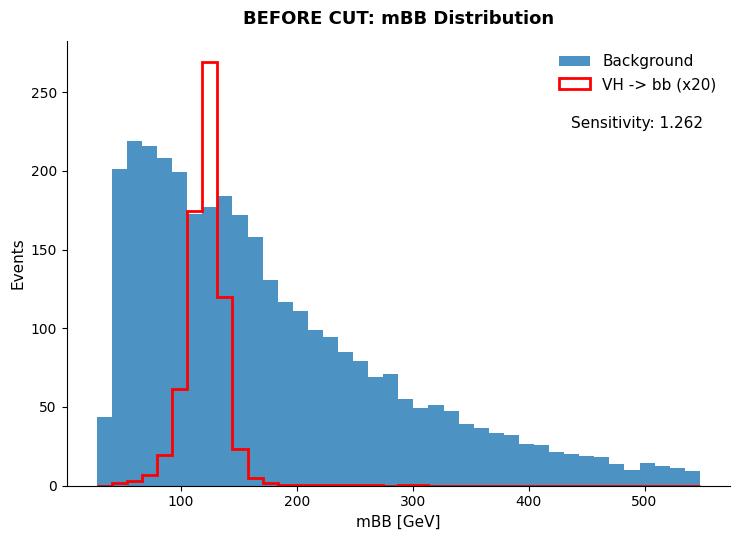

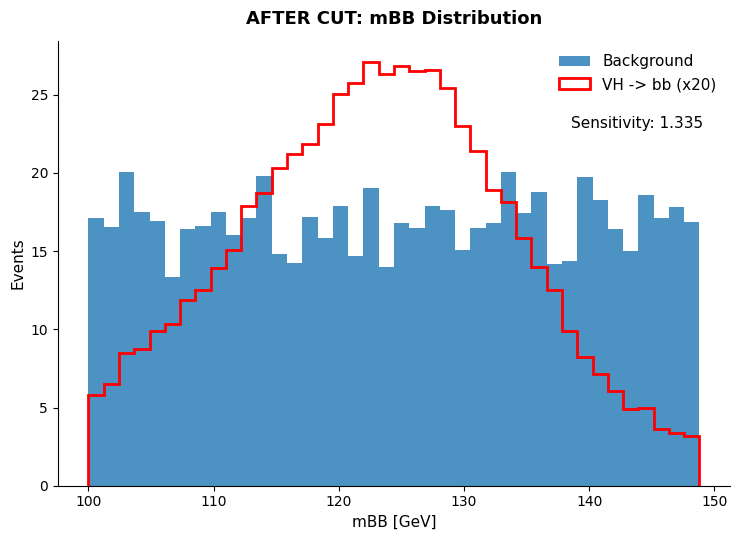


Parameter Analysis: dRBB  |  Applied Cut: dRBB > 0 and dRBB < 2.0


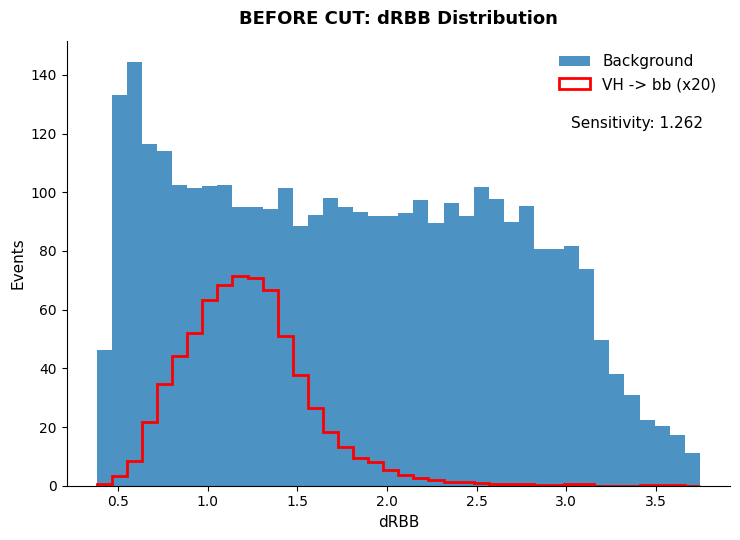

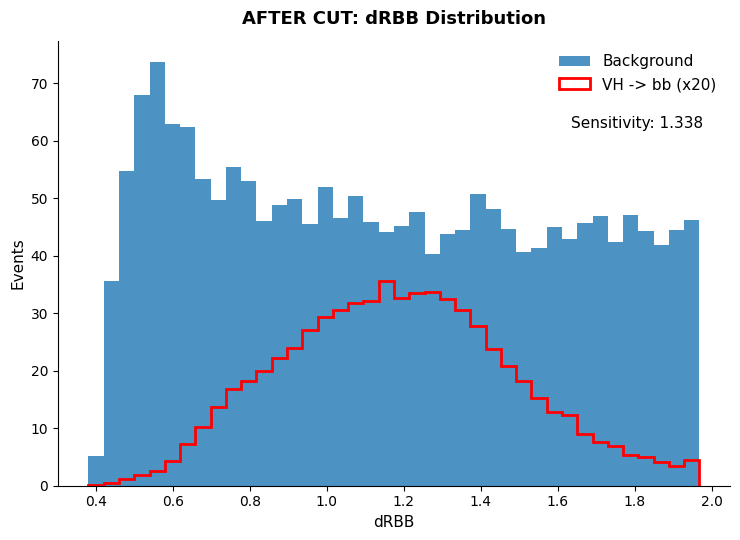


Parameter Analysis: pTV  |  Applied Cut: pTV > 150


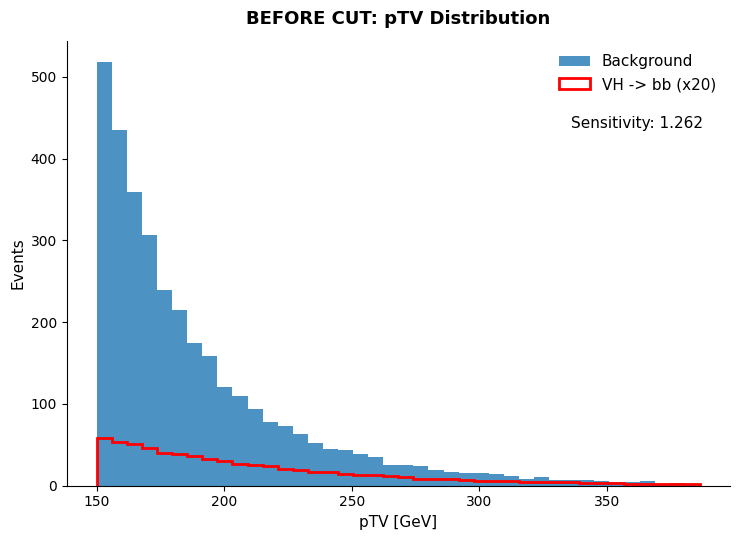

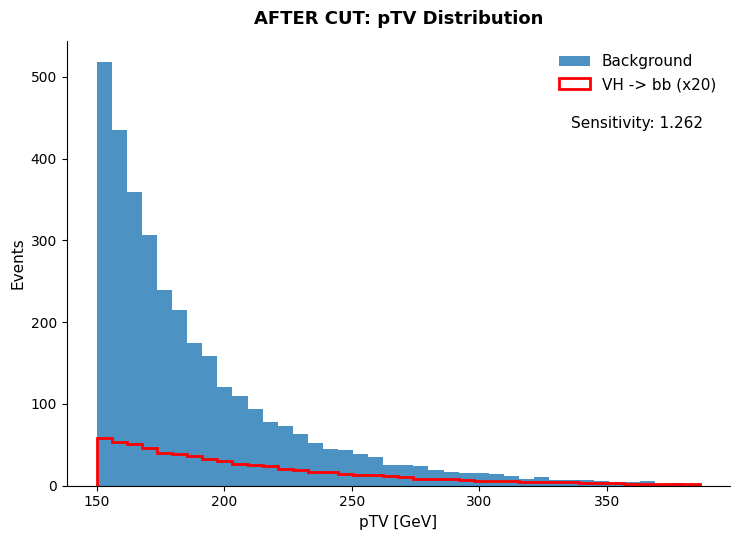


Parameter Analysis: MET  |  Applied Cut: MET > 30


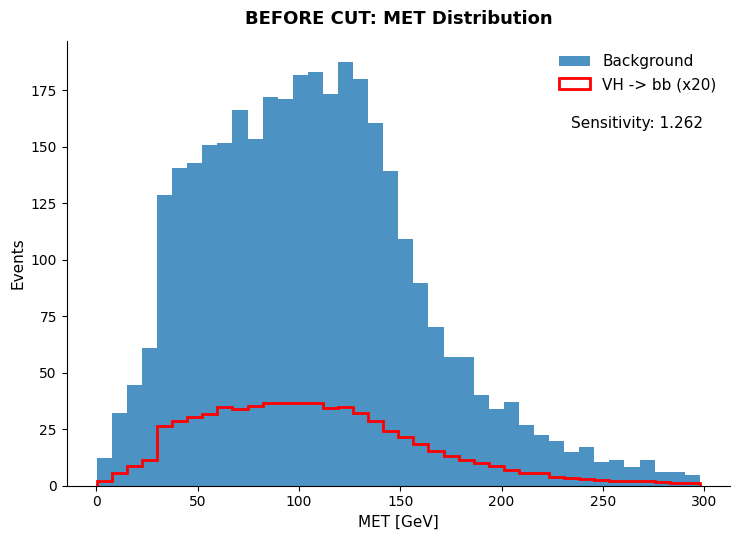

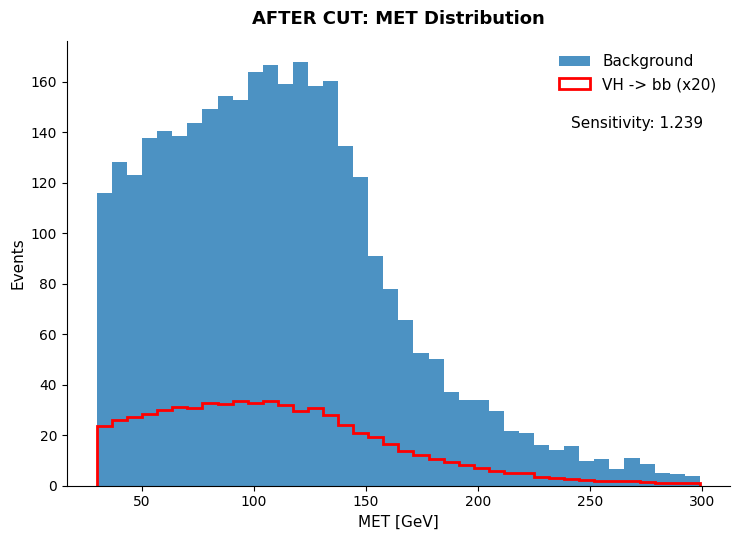


Parameter Analysis: Mtop  |  Applied Cut: Mtop > 0 and (Mtop < 150 or Mtop > 200)


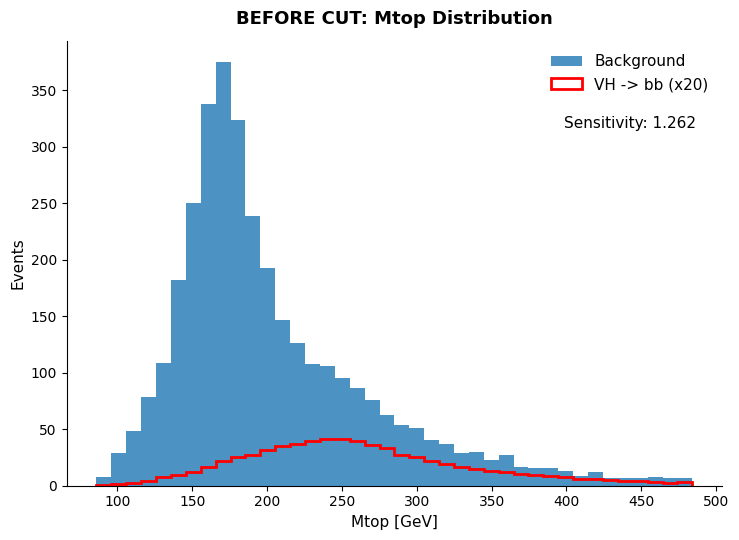

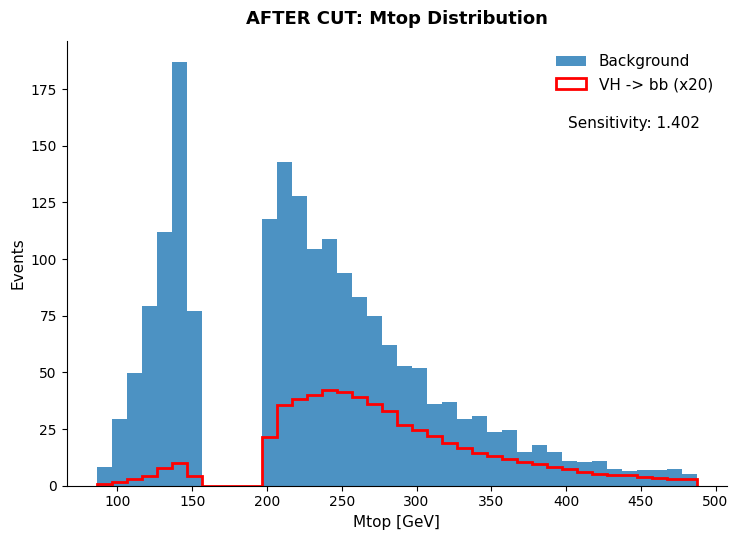



SUMMARY TABLE: CUT-BASED SENSITIVITY EVALUATION
References:
[1] ATLAS Collab., Phys. Lett. B 786 (2018) 59-86. (mBB and pTV cuts)
[2] ATLAS Collab., JHEP 01 (2015) 069. (MET and Mtop cuts)
[3] J. M. Butterworth et al., Phys. Rev. Lett. 100 (2008) 242001. (dRBB cut)
Parameter Cut Applied                             Sens. Before Sens. After Improvement (%)
 mBB                      mBB > 100 and mBB < 150 1.262        1.335        5.79%         
dRBB                      dRBB > 0 and dRBB < 2.0 1.262        1.338        6.02%         
 pTV                                    pTV > 150 1.262        1.262        0.00%         
 MET                                     MET > 30 1.262        1.239       -1.80%         
Mtop      Mtop > 0 and (Mtop < 150 or Mtop > 200) 1.262        1.402       11.14%         



In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def load_and_preprocess_data(filepath: str) -> pd.DataFrame:
    """
    Loads the ATLAS dataset, converts energy variables from MeV to GeV for standard IEEE reporting.
    """
    try:
        df = pd.read_csv(filepath)
        print(f"Dataset successfully loaded. Total initial events: {len(df)}")
    except FileNotFoundError:
        print(f"Error: Dataset not found at {filepath}.")
        raise

    # Convert MeV to GeV for academic standard plots (100,000 MeV -> 100 GeV)
    mev_columns = ['mBB', 'pTV', 'MET', 'Mtop', 'pTB1', 'pTB2', 'pTJ3', 'mBBJ', 'mTW']
    for col in mev_columns:
        if col in df.columns:
            df[col] = df[col] / 1000.0

    return df

def calculate_dynamic_sensitivity(df: pd.DataFrame, weight_col: str, bins: int = 30) -> float:
    """
    Calculates the signal sensitivity using DYNAMIC bin edges.
    This exactly replicates the ATLAS official sensitivity_cut_based() logic.
    """
    is_sig = (df['Class'] == 1) | (df['Class'] == 1.0) | (df['Class'] == 's') | (df['Class'] == '1')
    df_sig = df[is_sig]
    df_bkg = df[~is_sig]

    current_min, current_max = df['mBB'].min(), df['mBB'].max()

    s_hist, edges = np.histogram(df_sig['mBB'], bins=bins, range=(current_min, current_max), weights=df_sig[weight_col])
    b_hist, _ = np.histogram(df_bkg['mBB'], bins=edges, weights=df_bkg[weight_col])

    b_hist = np.where(b_hist <= 0, 1e-9, b_hist)
    return float(np.sqrt(np.sum((s_hist ** 2) / b_hist)))

def plot_official_style(df: pd.DataFrame, var: str, weight_col: str,
                        title: str, sensitivity: float):
    """
    Plots the distribution perfectly matching the ATLAS starter notebook style.
    Sensitivity is placed immediately below the top-right legend.
    """
    is_sig = (df['Class'] == 1) | (df['Class'] == 1.0) | (df['Class'] == 's') | (df['Class'] == '1')

    p_low, p_high = df[var].min(), df[var].quantile(0.995)

    plt.figure(figsize=(7.5, 5.5))

    # Background: Solid blue fill (Matching official notebook)
    plt.hist(df[~is_sig][var], bins=40, range=(p_low, p_high), weights=df[~is_sig][weight_col],
             color='#1f77b4', alpha=0.8, label='Background')

    # Signal: Solid red step line (Matching official notebook)
    scale_factor = 20
    plt.hist(df[is_sig][var], bins=40, range=(p_low, p_high), weights=df[is_sig][weight_col] * scale_factor,
             histtype='step', color='red', linewidth=2.0, label='VH -> bb (x20)')

    plt.title(title, fontsize=13, pad=12, fontweight='bold')
    plt.xlabel(f"{var} [GeV]" if var in ['mBB', 'pTV', 'MET', 'Mtop'] else var, fontsize=11)
    plt.ylabel("Events", fontsize=11)

    # Legend at the top right
    leg = plt.legend(loc='upper right', frameon=False, fontsize=11)

    # Sensitivity text directly below the legend
    plt.text(0.96, 0.83, f"Sensitivity: {sensitivity:.3f}", transform=plt.gca().transAxes,
             fontsize=11, verticalalignment='top', horizontalalignment='right')

    # Remove top and right spines for clean academic look
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

def evaluate_parameter_workflow(df: pd.DataFrame, var: str, cut_query: str):
    """
    Evaluates a single parameter before and after cuts.
    """
    weight_col = 'EventWeight' if 'EventWeight' in df.columns else 'training_weight'
    df_clean = df.dropna(subset=[var, 'mBB', weight_col, 'Class']).copy()

    print(f"\n{'='*75}\nParameter Analysis: {var}  |  Applied Cut: {cut_query}\n{'='*75}")

    # BEFORE CUT
    sens_before = calculate_dynamic_sensitivity(df_clean, weight_col)
    plot_official_style(df_clean, var, weight_col,
                        f"BEFORE CUT: {var} Distribution", sens_before)

    # AFTER CUT
    df_cut = df_clean.query(cut_query)
    sens_after = calculate_dynamic_sensitivity(df_cut, weight_col)
    plot_official_style(df_cut, var, weight_col,
                        f"AFTER CUT: {var} Distribution", sens_after)

    return sens_before, sens_after

# ==========================================
# Main Execution Block
# ==========================================
if __name__ == "__main__":
    FILE_PATH = '/VHbb_data_2jet_train.csv'
    df_main = load_and_preprocess_data(FILE_PATH)

    # Cuts adapted to GeV matching the official 100000-150000 MeV logic
    physics_cuts = {
        'mBB':  'mBB > 100 and mBB < 150',
        'dRBB': 'dRBB > 0 and dRBB < 2.0',
        'pTV':  'pTV > 150',
        'MET':  'MET > 30',
        'Mtop': 'Mtop > 0 and (Mtop < 150 or Mtop > 200)'
    }

    summary_results = []

    for variable, query_string in physics_cuts.items():
        if variable in df_main.columns:
            s_before, s_after = evaluate_parameter_workflow(df_main, variable, query_string)

            summary_results.append({
                'Parameter': variable,
                'Cut Applied': query_string,
                'Sens. Before': f"{s_before:.3f}",
                'Sens. After': f"{s_after:.3f}",
                'Improvement (%)': f"{((s_after - s_before) / s_before) * 100:.2f}%" if s_before > 0 else "0.00%"
            })

    # Print IEEE-Formatted Summary Table
    print("\n\n" + "="*85)
    print("SUMMARY TABLE: CUT-BASED SENSITIVITY EVALUATION")
    print("References:")
    print("[1] ATLAS Collab., Phys. Lett. B 786 (2018) 59-86. (mBB and pTV cuts)")
    print("[2] ATLAS Collab., JHEP 01 (2015) 069. (MET and Mtop cuts)")
    print("[3] J. M. Butterworth et al., Phys. Rev. Lett. 100 (2008) 242001. (dRBB cut)")
    print("="*85)
    summary_df = pd.DataFrame(summary_results)
    print(summary_df.to_string(index=False, justify='left'))
    print("="*85 + "\n")